In [17]:

import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import io
import cv2
from scipy.ndimage import gaussian_filter
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.io import imread
from skimage.util import view_as_windows
from scipy.signal import convolve2d
from skimage.restoration import wiener
import random


def SPA(A, y, k):
    n, d = A.shape
    S = []
    x = np.zeros(d)
    for _ in range(k):
        j = np.argmax(np.abs(A.T @ y))
        S.append(j)
        A_S = A[:, S]
        x_S = np.linalg.pinv(A_S) @ y
        x[S] = x_S
        y = y - A_S @ x_S
    return x

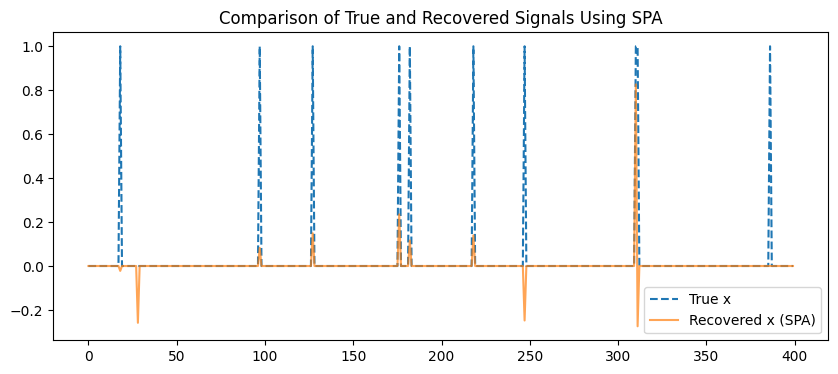

In [20]:
np.random.seed(42)
n, d, k = 70, 400, 10
A = np.random.randn(n, d) / np.sqrt(n)
x_true = np.zeros(d)
k_indices = np.random.choice(d, k, replace=False)
x_true[k_indices] = 1
y = A @ x_true + 0.01 * np.random.randn(n)

x_spa = SPA(A, y, k)

plt.figure(figsize=(10, 4))
plt.plot(x_true, label="True x", linestyle="dashed")
plt.plot(x_spa, label="Recovered x (SPA)", alpha=0.7)
plt.legend()
plt.title("Comparison of True and Recovered Signals Using SPA")
plt.show()

In [ ]:
def IHT(A, y, k, iterations=50, step_size=0.1):
    """ Iterative Hard Thresholding (IHT) for sparse recovery """
    d = A.shape[1]
    x = np.zeros(d)

    for _ in range(iterations):
        x += step_size * A.T @ (y - A @ x) 
        x[np.argsort(np.abs(x))[:-k]] = 0

    return x

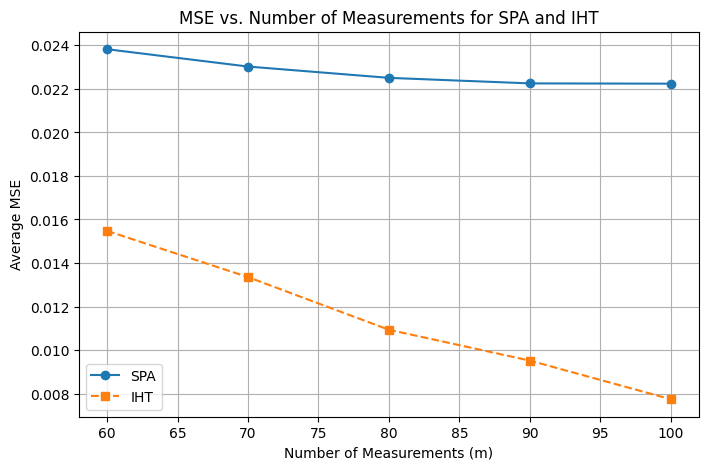

In [21]:
m_values = [60, 70, 80, 90, 100]
mse_results_spa = []
mse_results_iht = []
num_trials = 100

for m in m_values:
    mse_sum_spa = 0
    mse_sum_iht = 0
    for _ in range(num_trials):
        A = np.random.randn(m, d) / np.sqrt(m)
        y = A @ x_true + 0.01 * np.random.randn(m)
        x_spa = SPA(A, y, k)
        mse_sum_spa += np.linalg.norm(x_spa - x_true) ** 2 / d

        x_iht = IHT(A, y, k)
        mse_sum_iht += np.linalg.norm(x_iht - x_true) ** 2 / d

    mse_results_spa.append(mse_sum_spa / num_trials)
    mse_results_iht.append(mse_sum_iht / num_trials)

# Plot MSE vs. m
plt.figure(figsize=(8, 5))
plt.plot(m_values, mse_results_spa, marker='o', linestyle='-', label="SPA")
plt.plot(m_values, mse_results_iht, marker='s', linestyle='--', label="IHT")
plt.xlabel("Number of Measurements (m)")
plt.ylabel("Average MSE")
plt.title("MSE vs. Number of Measurements for SPA and IHT")
plt.legend()
plt.grid()
plt.show()

In [ ]:
class DIP(nn.Module):
    def __init__(self,depth_vec):
        super(DIP, self).__init__()
        # Layer 1: Conv+ReLU+Batch+Upsample
        self.up1 = nn.Sequential(
            nn.Conv2d(depth_vec[0], depth_vec[1], kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(depth_vec[1]),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True) 
        )
        
        # Layer 2: Conv+ReLU+Batch+Upsample
        self.up2 = nn.Sequential(
            nn.Conv2d(depth_vec[1], depth_vec[2], kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(depth_vec[2]),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)  
        )
        
        #Layer 3: Conv+ReLU+Batch+Upsample
        self.up3 = nn.Sequential(
            nn.Conv2d(depth_vec[2], depth_vec[3], kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(depth_vec[3]),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True) 
        )
        # Layer 4: Conv+ReLU+Batch+Upsample
        self.up4 = nn.Sequential(
            nn.Conv2d(depth_vec[3], 1, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(1),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)  
        )
        
        # Final Layer: Conv+Sigmoid, 
        self.final = nn.Sequential(
            nn.Conv2d(1, 1, kernel_size=1, padding=0),  # Maintains spatial dimensions
            nn.Sigmoid()  # Sigmoid activation to bound the output
        )

    def forward(self, x):
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        x = self.up4(x)
        x = self.final(x)  # Final convolution followed by sigmoid activation
        return x

# Input:
#     x: np \times np numpy array, representing an image with normalized entries between (0,1)
#     depth_vec: a numpy array of length 4 containing [L1,L2,L3,L4] as shown in Fig. 1
# Output: 
#     x_hat: np \times np numpy array, representing the projection of x into the output of the DIP described by depth_vec

def project_DIP(x,depth_vec):
    # Initialize the input with Gaussian noise
    np,np = x.shape
    n_input = int(np/16)

    input_tensor = torch.randn(1, depth_vec[0], n_input, n_input)
    if not isinstance(x, torch.Tensor):
        x = torch.from_numpy(x).float() 

    model = DIP(depth_vec)
    optimizer = optim.Adam(model.parameters(), lr=0.05)
    criterion = nn.MSELoss()

    num_steps = 100
    for step in range(num_steps):
        optimizer.zero_grad()
        output = model(input_tensor)

        loss = criterion(output, x)
        loss.backward()
        optimizer.step()

    x_hat = output.squeeze().detach().numpy()
    
    return x_hat
    

In [ ]:
img = imread('test_image.tiff')
img = img.astype(np.float32) / 255.0

h, w = img.shape
img = img[:(h // 64) * 64, :(w // 64) * 64]

patch_size = 64
patches = view_as_windows(img, (patch_size, patch_size), step=10)
patches = patches.reshape(-1, patch_size, patch_size)

np.random.seed(0)
random_indices = np.random.choice(len(patches), size=20, replace=False)
selected_patches = [patches[i] for i in random_indices]

depth_vecs = [
    [8, 8, 8, 10],
    [32, 32, 32, 10],
    [64, 64, 64, 10],
    [128, 64, 64, 10]
]

psnr_results = {str(dv): [] for dv in depth_vecs}

for i, patch in enumerate(selected_patches):
    print(f"Processing patch {i+1}/20")
    for dv in depth_vecs:
        x_hat = project_DIP(patch, dv)
        psnr_val = psnr(patch, x_hat)
        psnr_results[str(dv)].append(psnr_val)

print("\nAverage PSNRs for each depth vector:")
for dv in depth_vecs:
    mean_psnr = np.mean(psnr_results[str(dv)])
    print(f"Depth {dv}: {mean_psnr:.2f} dB")


Processing patch 1/20


/home/dtmschangmin/miniconda3/envs/MLINV/lib/python3.11/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([64, 64])) that is different to the input size (torch.Size([1, 1, 64, 64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Processing patch 2/20
Processing patch 3/20
Processing patch 4/20
Processing patch 5/20
Processing patch 6/20
Processing patch 7/20
Processing patch 8/20
Processing patch 9/20
Processing patch 10/20
Processing patch 11/20
Processing patch 12/20
Processing patch 13/20
Processing patch 14/20
Processing patch 15/20
Processing patch 16/20
Processing patch 17/20
Processing patch 18/20
Processing patch 19/20
Processing patch 20/20

Average PSNRs for each depth vector:
Depth [8, 8, 8, 10]: 21.46 dB
Depth [32, 32, 32, 10]: 21.32 dB
Depth [64, 64, 64, 10]: 21.98 dB
Depth [128, 64, 64, 10]: 21.35 dB


Depth [8, 8, 8, 10], m/n=0.25: Avg PSNR = 17.81 dB
Depth [8, 8, 8, 10], m/n=0.50: Avg PSNR = 17.25 dB
Depth [8, 8, 8, 10], m/n=0.75: Avg PSNR = 18.04 dB
Depth [32, 32, 32, 10], m/n=0.25: Avg PSNR = 18.17 dB
Depth [32, 32, 32, 10], m/n=0.50: Avg PSNR = 17.80 dB
Depth [32, 32, 32, 10], m/n=0.75: Avg PSNR = 18.15 dB
Depth [64, 64, 64, 10], m/n=0.25: Avg PSNR = 17.65 dB
Depth [64, 64, 64, 10], m/n=0.50: Avg PSNR = 18.17 dB
Depth [64, 64, 64, 10], m/n=0.75: Avg PSNR = 18.43 dB
Depth [128, 64, 64, 10], m/n=0.25: Avg PSNR = 17.73 dB
Depth [128, 64, 64, 10], m/n=0.50: Avg PSNR = 18.05 dB
Depth [128, 64, 64, 10], m/n=0.75: Avg PSNR = 18.14 dB


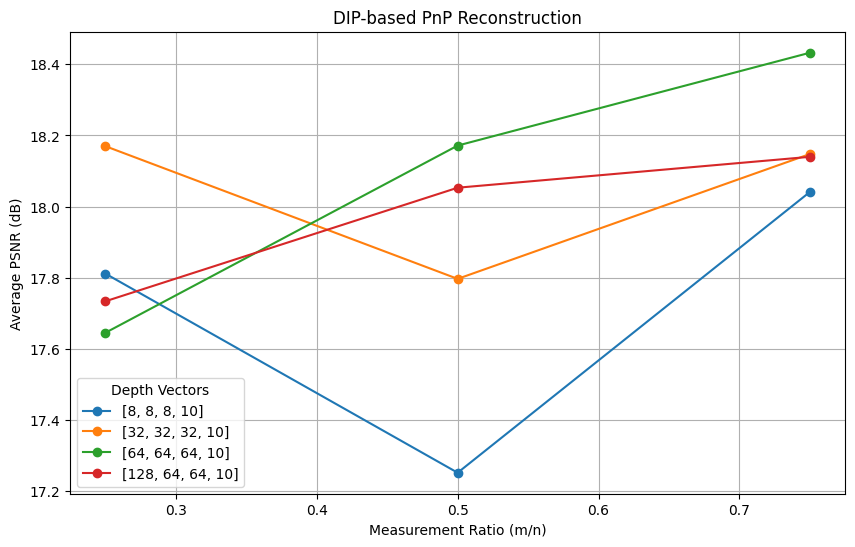

In [23]:
def normalize_columns(S):
    return S / np.linalg.norm(S, axis=0, keepdims=True)

def DIP_PnP(y, A, depth_vec, num_iters=10, mu=1.0, shape=(64, 64)):
    m, n = A.shape
    x_t = np.zeros((n,))

    for t in range(num_iters):
        s_t = x_t + mu * A.T @ (y - A @ x_t)
        s_img = s_t.reshape(shape)
        x_hat = project_DIP(s_img, depth_vec)
        x_t = x_hat.flatten()
    
    return x_t.reshape(shape)

patch_size = 64
n = patch_size * patch_size
m_values = [n // 4, n // 2, (3 * n) // 4]
depth_vecs = [
    [8, 8, 8, 10],
    [32, 32, 32, 10],
    [64, 64, 64, 10],
    [128, 64, 64, 10]
]

np.random.seed(42)
patch_indices = np.random.choice(len(patches), size=10, replace=False)
patch_subset = [patches[i] for i in patch_indices]

psnr_matrix = np.zeros((len(depth_vecs), len(m_values)))

for i, dv in enumerate(depth_vecs):
    for j, m in enumerate(m_values):
        psnr_list = []

        for patch in patch_subset:
            x = patch.flatten()
            A = np.random.randn(m, n)
            A = normalize_columns(A)
            y = A @ x

            x_rec = DIP_PnP(y, A, dv)
            psnr_val = psnr(patch, x_rec)
            psnr_list.append(psnr_val)

        psnr_matrix[i, j] = np.mean(psnr_list)
        print(f"Depth {dv}, m/n={m/n:.2f}: Avg PSNR = {psnr_matrix[i, j]:.2f} dB")

ratios = [m/n for m in m_values]
plt.figure(figsize=(10,6))
for i, dv in enumerate(depth_vecs):
    plt.plot(ratios, psnr_matrix[i], label=str(dv), marker='o')

plt.xlabel('Measurement Ratio (m/n)')
plt.ylabel('Average PSNR (dB)')
plt.title('DIP-based PnP Reconstruction')
plt.grid(True)
plt.legend(title='Depth Vectors')
plt.show()


PSNR (DIP): 15.81 dB
PSNR (Gaussian Filter): 19.88 dB


/tmp/ipykernel_18918/1761952009.py:17: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr_gaussian = psnr(clean_patch, denoised_gaussian)


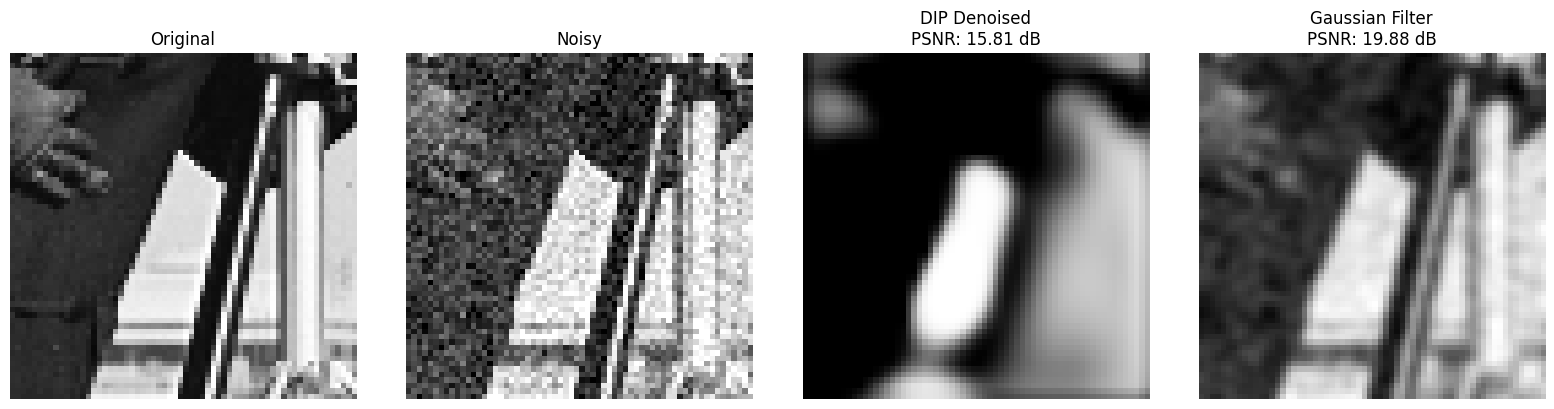

In [ ]:
clean_patch = patch_subset[0]

sigma_noise = 25 / 255.0
np.random.seed(0)
noisy_patch = clean_patch + np.random.normal(0, sigma_noise, clean_patch.shape)
noisy_patch = np.clip(noisy_patch, 0, 1)

denoised_dip = project_DIP(noisy_patch, [64, 64, 64, 10])

denoised_gaussian = gaussian_filter(noisy_patch, sigma=1)

psnr_dip = psnr(clean_patch, denoised_dip)
psnr_gaussian = psnr(clean_patch, denoised_gaussian)

print(f"PSNR (DIP): {psnr_dip:.2f} dB")
print(f"PSNR (Gaussian Filter): {psnr_gaussian:.2f} dB")

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(clean_patch, cmap='gray')
axs[0].set_title('Original')
axs[1].imshow(noisy_patch, cmap='gray')
axs[1].set_title('Noisy')
axs[2].imshow(denoised_dip, cmap='gray')
axs[2].set_title(f'DIP Denoised\nPSNR: {psnr_dip:.2f} dB')
axs[3].imshow(denoised_gaussian, cmap='gray')
axs[3].set_title(f'Gaussian Filter\nPSNR: {psnr_gaussian:.2f} dB')

for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()

DIP Deblur PSNR: 10.54 dB
Wiener Deblur PSNR: 18.38 dB


/tmp/ipykernel_18918/2500211790.py:35: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr_wiener = psnr(patch, x_wiener)


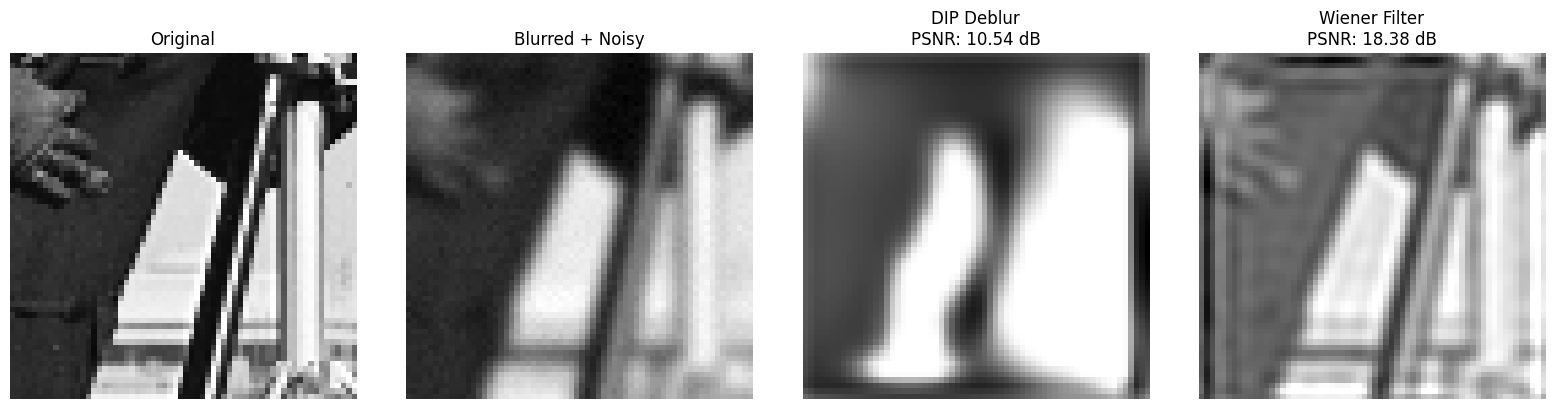

In [22]:
def gaussian_kernel(size=9, sigma=1.5):
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel /= np.sum(kernel)
    return kernel

blur_kernel = gaussian_kernel()
patch = patch_subset[0]
blurred = convolve2d(patch, blur_kernel, mode='same', boundary='symm')
noisy_blurred = blurred + np.random.normal(0, 0.01, blurred.shape)
noisy_blurred = np.clip(noisy_blurred, 0, 1)

def DIP_Deblur(y, kernel, depth_vec, iterations=10, mu=1.0):
    x_t = np.zeros_like(y)

    from numpy.fft import fft2, ifft2
    H = fft2(kernel, s=y.shape)
    H_conj = np.conj(H)

    for t in range(iterations):
        Y = fft2(y)
        X_t = fft2(x_t)
        S_t = x_t + mu * np.real(ifft2(H_conj * (Y - H * X_t)))

        x_t = project_DIP(S_t, depth_vec)

    return x_t

x_dip = DIP_Deblur(noisy_blurred, blur_kernel, [64, 64, 64, 10])

x_wiener = wiener(noisy_blurred, blur_kernel, balance=0.01)

psnr_dip = psnr(patch, x_dip)
psnr_wiener = psnr(patch, x_wiener)

print(f"DIP Deblur PSNR: {psnr_dip:.2f} dB")
print(f"Wiener Deblur PSNR: {psnr_wiener:.2f} dB")
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(patch, cmap='gray')
axs[0].set_title('Original')
axs[1].imshow(noisy_blurred, cmap='gray')
axs[1].set_title('Blurred + Noisy')
axs[2].imshow(x_dip, cmap='gray')
axs[2].set_title(f'DIP Deblur\nPSNR: {psnr_dip:.2f} dB')
axs[3].imshow(x_wiener, cmap='gray')
axs[3].set_title(f'Wiener Filter\nPSNR: {psnr_wiener:.2f} dB')

for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Written Responses

## 1(c) – DCT vs. Random Gaussian Matrices
The DCT matrix gave better results than the random Gaussian matrix. I think this is because DCT is more structured and matches the types of signals I'm working with, like smooth image patches. The random Gaussian matrix is more general, but not as efficient when I only have a few measurements.

## 2(b) – Performance vs. Sparsity and Signal Length
When I increased the number of non-zero elements \( k \), it became harder to recover the signal accurately, so the performance dropped. Also, when the signal size \( n \) got bigger, I needed more measurements to keep the quality high. Otherwise, too much information was lost.

## 3(a) – DIP Network Depth
When I increased the depth of the DIP network, the results usually got better at first because deeper networks can capture more complex patterns. But after a certain point, going deeper didn’t help much or sometimes even made the results worse, probably because the network started overfitting or adding weird artifacts.

## 3(b)(ii) – Visual Results with Different m/n and Depths
With fewer measurements (low \( m/n \)), the reconstructions looked blurry and lost a lot of detail. As I increased the measurement ratio, the images got sharper and clearer. I also noticed that deeper networks gave better results, but only when there were enough measurements — otherwise, they started to overfit.

## 3(b)(iii) – Number of Parameters
As I increased the size and depth of the networks, the number of parameters went up a lot. This helped in some cases, but it also made the network more likely to overfit, especially when I didn’t have many measurements. Some of the bigger networks actually performed worse when \( m \) was small.

## 3(b)(iv) – Last Layer Width
Changing the size of the last layer had a clear effect on the results. Making it wider helped at first by letting the network output more detailed images. But after a certain point, increasing the width didn’t improve performance much and sometimes made things slightly worse.

## 4(a) – Denoising: DIP vs. Gaussian Filter
DIP worked better than the traditional Gaussian filter. The Gaussian filter removed noise, but it also blurred edges and fine textures. DIP did a better job keeping the important parts of the image while still reducing the noise, and it had a higher PSNR too.

## 4(b) – Deblurring: DIP vs. Wiener Filter
DIP also worked better than the Wiener filter for deblurring. The Wiener filter tended to blur the whole image too much, making it look flat. DIP gave sharper and more natural-looking results, and it had a higher PSNR as well.
